<a href="https://colab.research.google.com/github/BrianLearning-source/PCVK_Genap_2026/blob/main/Week5_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **E-1 PERCOBAAN PRAKTIKUM**

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

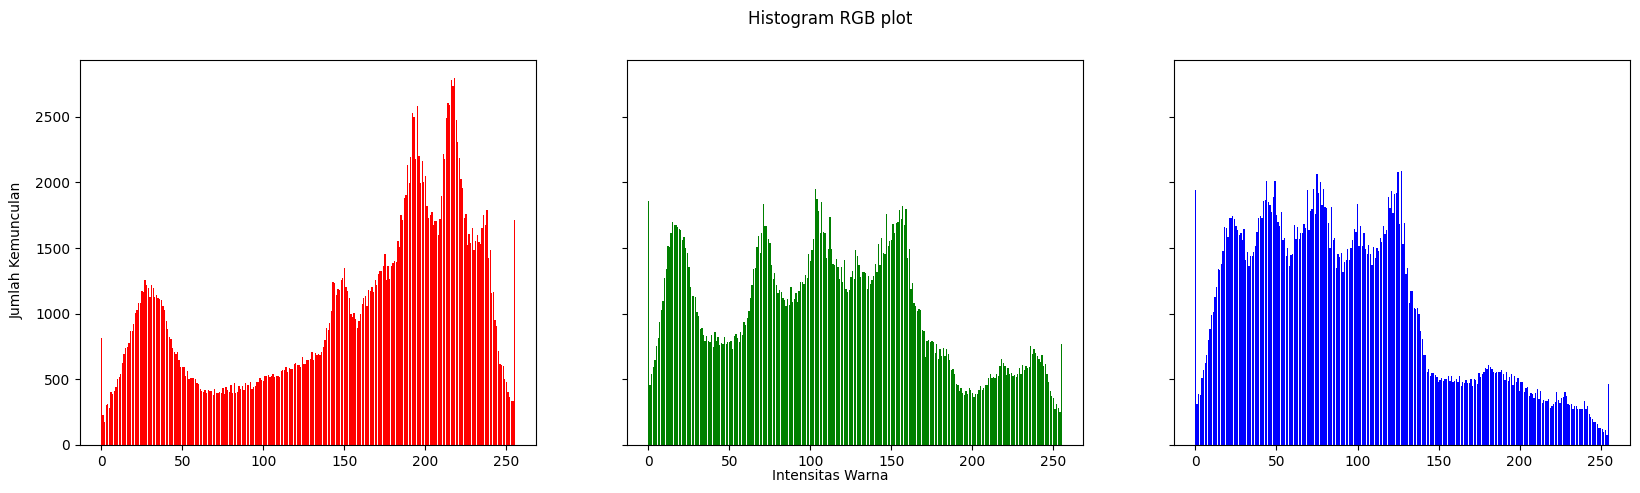

In [8]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
  for x in range(0, width):
    red[img[y] [x] [0]] += 1
    green[img[y] [x] [1]] += 1
    blue[img[y] [x] [2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

<BarContainer object of 256 artists>

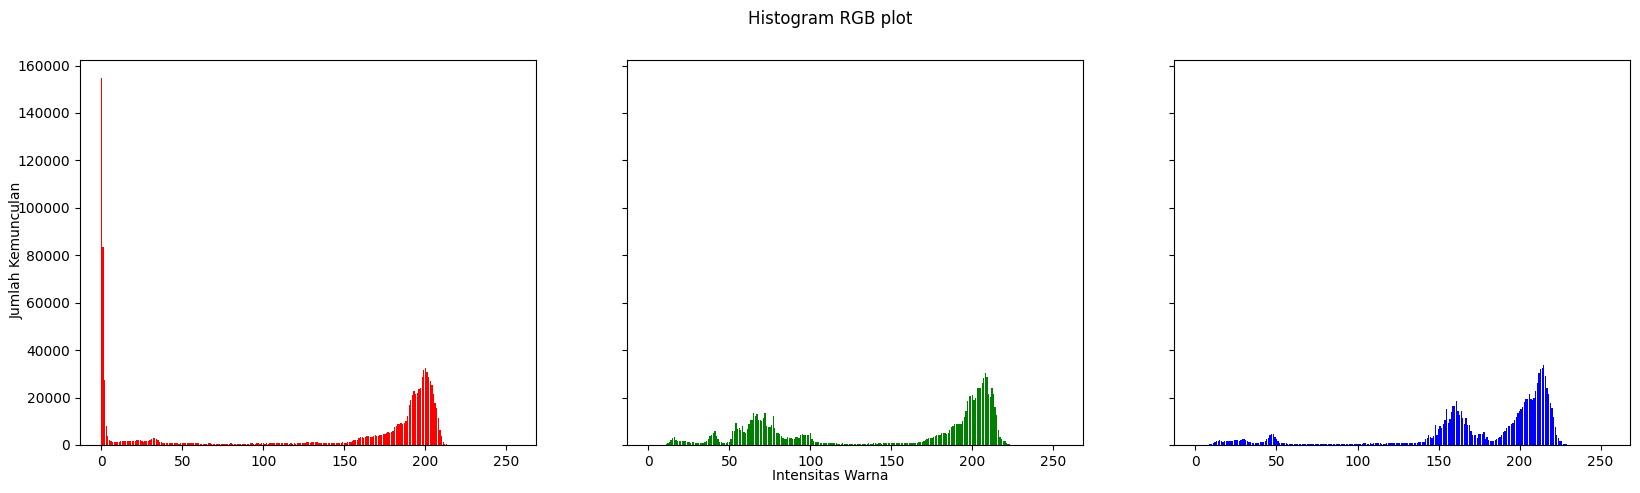

In [9]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/KTM.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
  for x in range(0, width):
    red[img[y] [x] [0]] += 1
    green[img[y] [x] [1]] += 1
    blue[img[y] [x] [2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

## **PERTANYAAN PRAKTIKUM E1**

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

## **Lena**

In [1]:
# Histogram manual
def histogram_manual(img):

    height, width, depth = np.shape(img)

    red = [0] * 256
    green = [0] * 256
    blue = [0] * 256

    for y in range(0, height):
        for x in range(0, width):

            red[img[y][x][0]] += 1
            green[img[y][x][1]] += 1
            blue[img[y][x][2]] += 1

    return np.array(red), np.array(green), np.array(blue)

In [2]:
# Histogram Numpy
def histogram_numpy(img):

    red, _ = np.histogram(
        img[:, :, 0],
        bins=256,
        range=(0, 256)
    )

    green, _ = np.histogram(
        img[:, :, 1],
        bins=256,
        range=(0, 256)
    )

    blue, _ = np.histogram(
        img[:, :, 2],
        bins=256,
        range=(0, 256)
    )

    return red, green, blue

In [3]:
# Histogram cv.calcHist()

def histogram_opencv(img):

    red = cv.calcHist(
        [img],
        [0],
        None,
        [256],
        [0, 256]
    ).flatten()

    green = cv.calcHist(
        [img],
        [1],
        None,
        [256],
        [0, 256]
    ).flatten()

    blue = cv.calcHist(
        [img],
        [2],
        None,
        [256],
        [0, 256]
    ).flatten()

    return red, green, blue

=== Selisih Histogram Lena ===
Red   : Manual vs NumPy  = 0
Red   : Manual vs OpenCV = 0
Green : Manual vs NumPy  = 0
Green : Manual vs OpenCV = 0
Blue  : Manual vs NumPy  = 0
Blue  : Manual vs OpenCV = 0


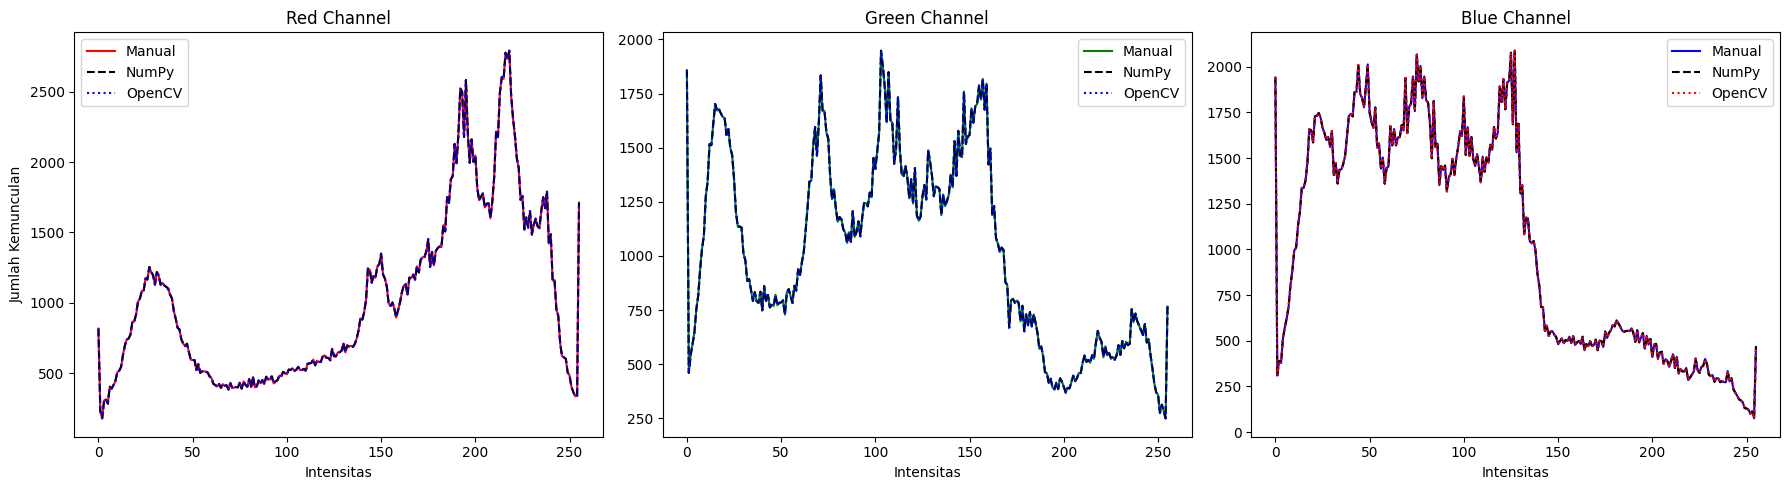

In [7]:
# Perbandingan ketiga histogram
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

  # def Histogram manual
manual_red, manual_green, manual_blue = histogram_manual(img)

  # def Histogram NumPy
numpy_red, numpy_green, numpy_blue = histogram_numpy(img)

  # def Histogram OpenCV
opencv_red, opencv_green, opencv_blue = histogram_opencv(img)

# Selisih Maksimum channel

# Selisih maksimum channel Red
diff_red_numpy = np.max(
    np.abs(manual_red.astype(np.int64) -
           numpy_red.astype(np.int64))
)

diff_red_opencv = np.max(
    np.abs(manual_red.astype(np.int64) -
           opencv_red.astype(np.int64))
)

# Selisih maksimum channel Green
diff_green_numpy = np.max(
    np.abs(manual_green.astype(np.int64) -
           numpy_green.astype(np.int64))
)

diff_green_opencv = np.max(
    np.abs(manual_green.astype(np.int64) -
           opencv_green.astype(np.int64))
)

# Selisih maksimum channel Blue
diff_blue_numpy = np.max(
    np.abs(manual_blue.astype(np.int64) -
           numpy_blue.astype(np.int64))
)

diff_blue_opencv = np.max(
    np.abs(manual_blue.astype(np.int64) -
           opencv_blue.astype(np.int64))
)

print("=== Selisih Histogram Lena ===")

print("Red   : Manual vs NumPy  =", diff_red_numpy)
print("Red   : Manual vs OpenCV =", diff_red_opencv)

print("Green : Manual vs NumPy  =", diff_green_numpy)
print("Green : Manual vs OpenCV =", diff_green_opencv)

print("Blue  : Manual vs NumPy  =", diff_blue_numpy)
print("Blue  : Manual vs OpenCV =", diff_blue_opencv)

# Pembuktian Histogram

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(names, manual_red, color='red', label='Manual')
axs[0].plot(names, numpy_red, '--', color='black', label='NumPy')
axs[0].plot(names, opencv_red, ':', color='blue', label='OpenCV')
axs[0].set_title('Red Channel')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Kemunculan')
axs[0].legend()

axs[1].plot(names, manual_green, color='green', label='Manual')
axs[1].plot(names, numpy_green, '--', color='black', label='NumPy')
axs[1].plot(names, opencv_green, ':', color='blue', label='OpenCV')
axs[1].set_title('Green Channel')
axs[1].set_xlabel('Intensitas')
axs[1].legend()

axs[2].plot(names, manual_blue, color='blue', label='Manual')
axs[2].plot(names, numpy_blue, '--', color='black', label='NumPy')
axs[2].plot(names, opencv_blue, ':', color='red', label='OpenCV')
axs[2].set_title('Blue Channel')
axs[2].set_xlabel('Intensitas')
axs[2].legend()

plt.tight_layout()
plt.show()

## **KTM**

=== Selisih Histogram KTM1b ===
Red   : Manual vs NumPy  = 0
Red   : Manual vs OpenCV = 0
Green : Manual vs NumPy  = 0
Green : Manual vs OpenCV = 0
Blue  : Manual vs NumPy  = 0
Blue  : Manual vs OpenCV = 0


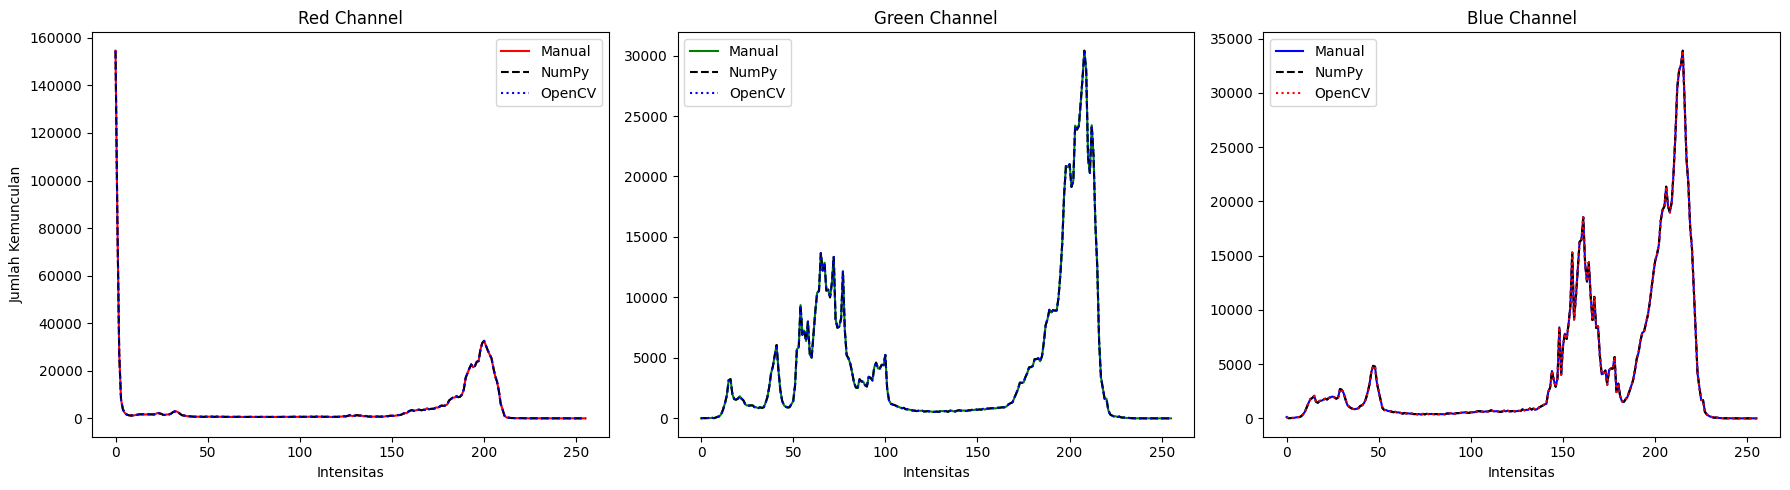

In [10]:
img = cv.imread('/content/drive/MyDrive/PCVK/KTM.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Histogram manual
manual_red, manual_green, manual_blue = histogram_manual(img)
# Histogram numpy
numpy_red, numpy_green, numpy_blue = histogram_numpy(img)
# Histogram openCV
opencv_red, opencv_green, opencv_blue = histogram_opencv(img)

diff_red_numpy = np.max(
    np.abs(manual_red.astype(np.int64) -
           numpy_red.astype(np.int64))
)

diff_red_opencv = np.max(
    np.abs(manual_red.astype(np.int64) -
           opencv_red.astype(np.int64))
)

diff_green_numpy = np.max(
    np.abs(manual_green.astype(np.int64) -
           numpy_green.astype(np.int64))
)

diff_green_opencv = np.max(
    np.abs(manual_green.astype(np.int64) -
           opencv_green.astype(np.int64))
)

diff_blue_numpy = np.max(
    np.abs(manual_blue.astype(np.int64) -
           numpy_blue.astype(np.int64))
)

diff_blue_opencv = np.max(
    np.abs(manual_blue.astype(np.int64) -
           opencv_blue.astype(np.int64))
)

print("=== Selisih Histogram KTM1b ===")

print("Red   : Manual vs NumPy  =", diff_red_numpy)
print("Red   : Manual vs OpenCV =", diff_red_opencv)

print("Green : Manual vs NumPy  =", diff_green_numpy)
print("Green : Manual vs OpenCV =", diff_green_opencv)

print("Blue  : Manual vs NumPy  =", diff_blue_numpy)
print("Blue  : Manual vs OpenCV =", diff_blue_opencv)

# Pembuktian Histogram

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(names, manual_red, color='red', label='Manual')
axs[0].plot(names, numpy_red, '--', color='black', label='NumPy')
axs[0].plot(names, opencv_red, ':', color='blue', label='OpenCV')
axs[0].set_title('Red Channel')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Kemunculan')
axs[0].legend()

axs[1].plot(names, manual_green, color='green', label='Manual')
axs[1].plot(names, numpy_green, '--', color='black', label='NumPy')
axs[1].plot(names, opencv_green, ':', color='blue', label='OpenCV')
axs[1].set_title('Green Channel')
axs[1].set_xlabel('Intensitas')
axs[1].legend()

axs[2].plot(names, manual_blue, color='blue', label='Manual')
axs[2].plot(names, numpy_blue, '--', color='black', label='NumPy')
axs[2].plot(names, opencv_blue, ':', color='red', label='OpenCV')
axs[2].set_title('Blue Channel')
axs[2].set_xlabel('Intensitas')
axs[2].legend()

plt.tight_layout()
plt.show()

2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.